# 1km 격자별 총인구수 데이터 구축

통계지리정보서비스(SGIS) 2024년 인구 격자 데이터에서 대상 지역(대구경북 17개 행정경계)과
겹치는 1km 격자만 추출하고, 격자별 총인구수(`to_in_001`)를 결합한다. Gaussian 2SFCA의
demand(수요) 레이어로 사용한다.

## 원본 데이터

| 데이터 | 설명 |
|---|---|
| `raw_grid_1km/grid_{라마,라바,마마,마바}_1K.shp` | SGIS 1km 격자 경계(폴리곤), 국가 표준 격자 코드 4개 타일(대구경북 권역 포함) |
| `_census_reqdoc_1788834900759/2024년_인구_{타일}_1K.csv` | 격자 코드별 인구 통계(연도, GRID_CD, 항목코드, 값)의 long format. `to_in_001`=총인구수, `to_in_007`/`to_in_008`=성별 인구, `in_age_*`=연령별 인구 |

**참고**: 인구가 매우 적거나 0에 가까운 격자는 통계 보호를 위해 원본에 항목 자체가 누락되어
있는 것으로 보인다 — 이 노트북에서는 누락된 격자를 총인구수 0으로 처리한다.

In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

## 1. 1km 격자 경계 로드 (4개 타일 결합)

In [2]:
TILES = ["라마", "라바", "마마", "마바"]

grids = []
for t in TILES:
    g = gpd.read_file(f"data/raw_grid_1km/grid_{t}_1K.shp", encoding="utf-8")
    grids.append(g)
    print(f"{t}: {len(g)}개")

grid = gpd.GeoDataFrame(pd.concat(grids, ignore_index=True), crs=grids[0].crs)
print(f"\n타일 4개 합계: {len(grid)}개 (unique GRID_CD: {grid['GRID_CD'].nunique()}개)")
grid.head()

라마: 10000개
라바: 10000개
마마: 7721개
마바: 7265개

타일 4개 합계: 34986개 (unique GRID_CD: 34986개)


,GRID_CD,geometry
0,라마0000,"POLYGON ((1000000 1700000, 1000000 1701000, 10..."
1,라마0001,"POLYGON ((1000000 1701000, 1000000 1702000, 10..."
2,라마0002,"POLYGON ((1000000 1702000, 1000000 1703000, 10..."
3,라마0003,"POLYGON ((1000000 1703000, 1000000 1704000, 10..."
4,라마0004,"POLYGON ((1000000 1704000, 1000000 1705000, 10..."


## 2. 격자별 총인구수 로드 (`to_in_001`)

CSV에 헤더가 없어 컬럼명을 직접 지정한다(`year, GRID_CD, item, value`).

In [3]:
CENSUS_DIR = "/Users/chaelyn/Downloads/_census_reqdoc_1788834900759"

pops = []
for t in TILES:
    df = pd.read_csv(
        f"{CENSUS_DIR}/2024년_인구_{t}_1K.csv", encoding="cp949", header=None,
        names=["year", "GRID_CD", "item", "value"],
    )
    pops.append(df)

census = pd.concat(pops, ignore_index=True)
tot_pop = census[census["item"] == "to_in_001"][["GRID_CD", "value"]].rename(columns={"value": "TOT_POP"})
print(f"총인구수(to_in_001) 레코드: {len(tot_pop)}개, 중복 GRID_CD: {tot_pop['GRID_CD'].duplicated().sum()}개")
tot_pop["TOT_POP"].describe()

총인구수(to_in_001) 레코드: 24424개, 중복 GRID_CD: 0개


count    24424.000000
mean       319.674460
std       1675.420704
min          0.000000
25%          8.000000
50%         33.000000
75%         83.000000
max      30913.000000
Name: TOT_POP, dtype: float64

## 3. 격자 경계 + 총인구수 결합

인구 레코드가 없는 격자는 총인구수 0으로 채운다.

In [4]:
grid = grid.merge(tot_pop, on="GRID_CD", how="left")
n_missing = grid["TOT_POP"].isna().sum()
grid["TOT_POP"] = grid["TOT_POP"].fillna(0).astype(int)
print(f"인구 레코드 없어 0으로 채운 격자: {n_missing}개 / {len(grid)}개")
grid["TOT_POP"].describe()

인구 레코드 없어 0으로 채운 격자: 10562개 / 34986개


count    34986.000000
mean       223.167238
std       1407.524916
min          0.000000
25%          0.000000
50%         13.000000
75%         53.000000
max      30913.000000
Name: TOT_POP, dtype: float64

## 4. 대상 시군구(17개 행정경계)와 교차하는 격자만 추출

In [5]:
sigungu = gpd.read_file("data/BND_SIGUNGU_PG/BND_SIGUNGU_PG.shp", encoding="cp949")
target_codes = [
    "22010", "22020", "22030", "22040", "22050", "22060", "22070", "22510", "22520",
    "37050", "37030", "37070", "37100", "37560", "37570", "37580", "37590",
]
target_sigungu = sigungu[sigungu["SIGUNGU_CD"].isin(target_codes)].to_crs(grid.crs)
target_union = target_sigungu.union_all()

grid_clipped = grid[grid.intersects(target_union)].copy()
print(f"대상 시군구와 교차하는 1km 격자: {len(grid_clipped)}개 / {len(grid)}개")
print(f"총인구수 합계: {grid_clipped['TOT_POP'].sum():,}명")

대상 시군구와 교차하는 1km 격자: 6878개 / 34986개
총인구수 합계: 3,538,987명


## 5. 저장

In [6]:
import os

out_dir = "data/grid_1km_population_daegugyeongbuk"
os.makedirs(out_dir, exist_ok=True)
out_path = f"{out_dir}/grid_1km_population_daegugyeongbuk.shp"

grid_clipped[["GRID_CD", "TOT_POP", "geometry"]].to_file(out_path, encoding="utf-8")
print("저장 완료:", out_path)

저장 완료: data/grid_1km_population_daegugyeongbuk/grid_1km_population_daegugyeongbuk.shp


## 6. 시각화

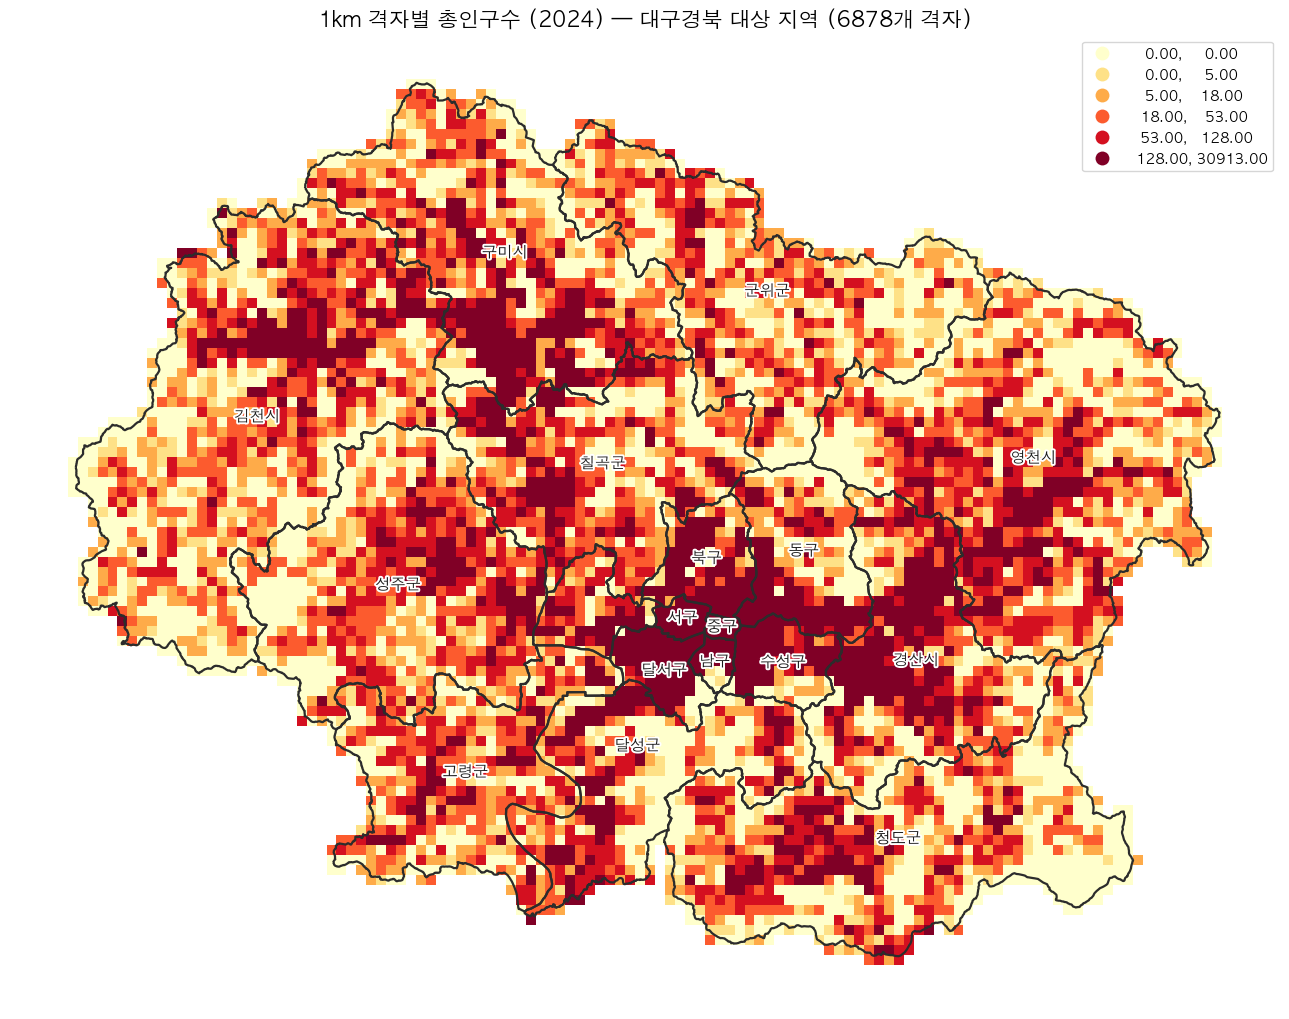

In [7]:
fig, ax = plt.subplots(figsize=(13, 13), facecolor="white")

grid_clipped.plot(
    ax=ax, column="TOT_POP", cmap="YlOrRd", scheme="quantiles", k=6,
    legend=True, edgecolor="none", zorder=1,
)
target_sigungu.boundary.plot(ax=ax, color="#2c2c2c", linewidth=1.6, zorder=2)
for _, row in target_sigungu.iterrows():
    c = row.geometry.centroid
    ax.annotate(
        row["SIGUNGU_NM"], xy=(c.x, c.y), ha="center", va="center",
        fontsize=11, fontweight="bold", color="#1a1a1a", zorder=3,
        path_effects=[pe.withStroke(linewidth=2.8, foreground="white")],
    )

ax.set_title(f"1km 격자별 총인구수 (2024) — 대구경북 대상 지역 ({len(grid_clipped)}개 격자)",
             fontsize=15, fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.savefig("data/grid_1km_population_daegugyeongbuk/population_grid_map.png", dpi=200, facecolor="white")
plt.show()